In [2]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv('heart_disease_dataset,,,csv.csv')

In [4]:
df.tail()
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [5]:
df.describe()

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,52.293000,249.939000,135.2810,79.204000,4.529000,5.646000,134.941000,0.392000
std,15.727126,57.914673,26.3883,11.486092,2.934241,2.831024,36.699624,0.488441
min,25.000000,150.000000,90.0000,60.000000,0.000000,1.000000,70.000000,0.000000
25%,39.000000,200.000000,112.7500,70.000000,2.000000,3.000000,104.000000,0.000000
50%,52.000000,248.000000,136.0000,79.000000,4.500000,6.000000,135.000000,0.000000
75%,66.000000,299.000000,159.0000,89.000000,7.000000,8.000000,167.000000,1.000000
max,79.000000,349.000000,179.0000,99.000000,9.000000,10.000000,199.000000,1.000000


In [6]:
X = df.drop("Heart Disease",axis = 1)
y = df["Heart Disease"]

In [7]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include = "str").columns

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        ("num",StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state = 42,
    test_size=0.20
)

In [10]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled,y_train)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [12]:
y_pred = knn.predict(X_test_scaled)

In [13]:
from sklearn.metrics import(
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print(f"AUURACY SCORE :{accuracy_score(y_test,y_pred)}")
print(f"PRECISION SCORE :{precision_score(y_test,y_pred)}")
print(f"RECALL SCORE :{recall_score(y_test,y_pred)}")
print(f"F1 SCORE :{f1_score(y_test,y_pred)}")
print(f"classification report :{classification_report(y_test,y_pred)}")

AUURACY SCORE :0.86
PRECISION SCORE :0.8048780487804879
RECALL SCORE :0.8461538461538461
F1 SCORE :0.825
classification report :              precision    recall  f1-score   support

           0       0.90      0.87      0.88       122
           1       0.80      0.85      0.82        78

    accuracy                           0.86       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.86      0.86      0.86       200



In [20]:
# 1. Fixed `.13` to `13`
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21] 

# 2. Renamed lists to avoid overwriting function names
accuracies = [] 
precisions = [] 
recalls = [] 
f1s = [] 

for k in k_values:
    test_knn = KNeighborsClassifier(n_neighbors=k)
    test_knn.fit(X_train_scaled, y_train)
    test_knn_pred = test_knn.predict(X_test_scaled)
    
    # 3. Appending using the correct function names
    accuracies.append(accuracy_score(y_test, test_knn_pred))
    precisions.append(precision_score(y_test, test_knn_pred)) # Fixed typo 'precision_scoree'
    recalls.append(recall_score(y_test, test_knn_pred))
    f1s.append(f1_score(y_test, test_knn_pred))

# 4. Creating the DataFrame
test_knn_results = pd.DataFrame({
    "kvalues": k_values,
    "accuracies": accuracies,
    "precisions": precisions,
    "recall scores": recalls,
    "f1 scores": f1s
})

print(test_knn_results)

    kvalues  accuracies  precisions  recall scores  f1 scores
0         1       0.795    0.740260       0.730769   0.735484
1         3       0.885    0.866667       0.833333   0.849673
2         5       0.860    0.804878       0.846154   0.825000
3         7       0.885    0.866667       0.833333   0.849673
4         9       0.875    0.853333       0.820513   0.836601
5        11       0.905    0.915493       0.833333   0.872483
6        13       0.900    0.914286       0.820513   0.864865
7        15       0.900    0.902778       0.833333   0.866667
8        17       0.885    0.887324       0.807692   0.845638
9        19       0.900    0.902778       0.833333   0.866667
10       21       0.900    0.902778       0.833333   0.866667


In [17]:
best_k_value_index = np.argmax(f1s)

print(best_k_value_index)

5


In [19]:
best_knn = KNeighborsClassifier(
    n_neighbors=k_values[best_k_value_index]
)

best_knn.fit(X_train_scaled,y_train)

y_pred_fin = best_knn.predict(X_test_scaled)

print(f"BEST AUURACY SCORE :{accuracy_score(y_test,y_pred_fin)}")
print(f"BEST PRECISION SCORE :{precision_score(y_test,y_pred_fin)}")
print(f"BEST RECALL SCORE :{recall_score(y_test,y_pred_fin)}")
print(f"BEST F1 SCORE :{f1_score(y_test,y_pred_fin)}")
print(f"BEST classification report :{classification_report(y_test,y_pred_fin)}")


BEST AUURACY SCORE :0.905
BEST PRECISION SCORE :0.9154929577464789
BEST RECALL SCORE :0.8333333333333334
BEST F1 SCORE :0.87248322147651
BEST classification report :              precision    recall  f1-score   support

           0       0.90      0.95      0.92       122
           1       0.92      0.83      0.87        78

    accuracy                           0.91       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.91      0.91      0.90       200



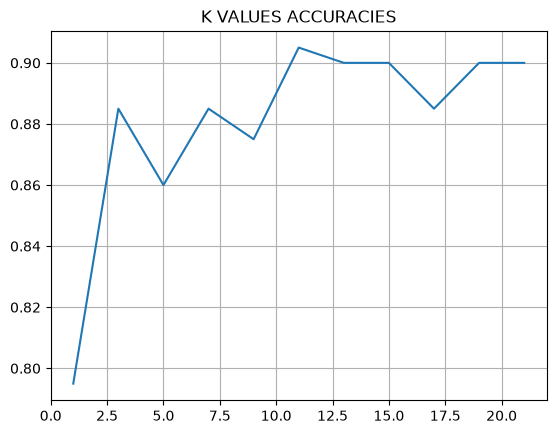

In [22]:
import matplotlib.pyplot as plt 

plt.plot(k_values,accuracies)
plt.title(f"K VALUES ACCURACIES")
plt.grid()
plt.show()